# How to Make Catalog Selections

In [5]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.vizier import Vizier
from astroquery.ipac.irsa.ibe import Ibe
from astroquery.ipac.irsa import Irsa
from astropy import table
from astropy.table import Table, Column, MaskedColumn
import matplotlib.pyplot as plt
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
import reproject
from reproject.mosaicking import find_optimal_celestial_wcs

In [1]:
cd ../smart-plotters/

/blue/adamginsburg/savannahgramze/cloudc/smart-plotters/smart-plotters


In [2]:
from cutout_plot import Cutout
from glimpse_plots import GlimpseCatalog
from surface_density_plot import gutermuth_stellar_density

In [3]:
cd ../tutorials/

/blue/adamginsburg/savannahgramze/cloudc/smart-plotters/tutorials


Making catalog selections, that is, selecting certain parts of a catalog for further analysis, is an essential skill for astronomers working with large catalogs of stars. 

These selections may be made spatially, examining a certain part of the sky. They may also be made in magnitude and/or color space. 

Let's start with a spatial selection.

In [6]:
# Let's take a look at a star formation region, W51, and try to select the YSOs
position = SkyCoord.from_name('W51')
l = w = 15*u.arcmin
position.galactic

<SkyCoord (Galactic): (l, b) in deg
    (49.14044508, -0.60277894)>

In [7]:
# We will use the GLIMPSE survey, which observed the Galactic Plane with Spitzer
Vizier.ROW_LIMIT = 1e6
Vizier.TIMEOUT = 1800
Vizier.VIZIER_SERVER = 'vizier.cfa.harvard.edu/'

catalog_name = 'II/293/glimpse'
# Querying the catalog spatially as we do below is already a form of catalog selection. 
catalog = Vizier.query_region(coordinates=position, width=w, height=l, catalog=[catalog_name])[0]
# We could also query the entire catalog, as below, and then make our own spatial selection. 
# However, the entire GLIMPSE catalog has over 1e8 sources, for more than is reasonable to work with. 
#catalog = Vizier.get_catalogs(catalog_name)[0]
catalog[:3]

GLIMPSE,RAJ2000,DEJ2000,C,2MASS,Jmag,Hmag,Kmag,3.6mag,e_3.6mag,4.5mag,e_4.5mag,5.8mag,e_5.8mag,8.0mag,e_8.0mag
,deg,deg,,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag
str17,float64,float64,str1,str16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
G049.0333-00.6661,290.963650,13.975655,A,,--,--,--,15.304,0.168,14.824,0.217,--,--,--,--
G049.0118-00.6265,290.917287,13.975458,A,,--,--,--,14.980,0.203,--,--,--,--,--,--
G049.0128-00.6289,290.919923,13.975155,C,,--,--,--,14.266,0.146,14.128,0.207,--,--,--,--


In [8]:
# To make a spatial selection, we need an image to work with. 
# Following the instructions for how to do an image query 
# via https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html
spitzer_images = Irsa.query_sia(pos=(position, 1 * u.arcsec), collection='spitzer_seip').to_table()
sel = np.logical_and(spitzer_images['dataproduct_subtype'] == 'science', spitzer_images['instrument_name'] == 'IRAC')
science_image = spitzer_images[sel][11]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=position, size=2 * u.arcmin, wcs=WCS(hdul[0].header))


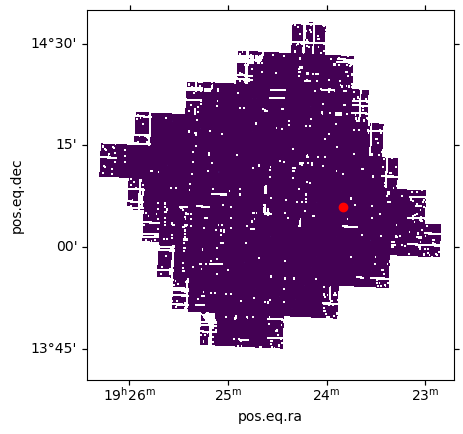

In [9]:
## These steps should help in cases where the cutout queried above is full of NaNs.
## Make sure that the position overlaps with the image!
hdul = fits.open(science_image['access_url'], use_fsspec=True) # for checking the 
ax = plt.subplot(projection=WCS(hdul[0].header))
ax.imshow(hdul[0].data)
ax.scatter(position.ra, position.dec, transform=ax.get_transform('world'), color='r')#transform=ax.get_transform('world')

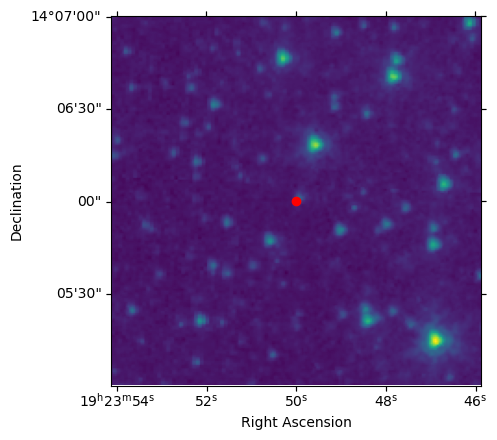

In [10]:
ax = plt.subplot(projection=cutout.wcs)
norm = simple_norm(cutout.data, stretch='log')
ax.imshow(cutout.data, norm=norm)
ax.scatter(position.ra, position.dec, transform=ax.get_transform('world'), color='r')#transform=ax.get_transform('world')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

In [11]:
# Now, let's find the stars within the selected area of the sky
# For now, let's extract the coordinates of the stars in the catalog
catalog_coords = SkyCoord(ra=catalog['RAJ2000'], dec=catalog['DEJ2000'], unit=(u.deg, u.deg), frame='fk5')

In [12]:
# Now we make a region at the position with the size on the sky we cut out
reg = regions.RectangleSkyRegion(position, 2*u.arcmin, 2*u.arcmin)

# Any astropy sky region works for this, even a polygon region made using ds9 or Carta

In [13]:
# Using the sky region's function contains, we can select for coordinates within the region
catalog_in = catalog[reg.contains(catalog_coords, cutout.wcs)]
catalog_coords_in = catalog_coords[reg.contains(catalog_coords, cutout.wcs)]

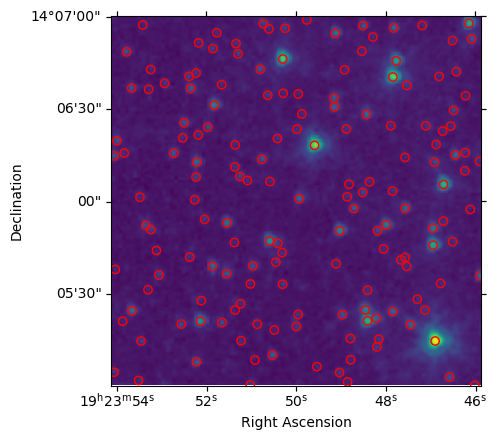

In [14]:
ax = plt.subplot(projection=cutout.wcs)
norm = simple_norm(cutout.data, stretch='log')
ax.imshow(cutout.data, norm=norm)
ax.scatter(catalog_coords_in.ra, catalog_coords_in.dec, transform=ax.get_transform('world'), edgecolor='r', facecolor='None')#transform=ax.get_transform('world')
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')

Now, let's look into how to do further selections of the catalog. 

In [15]:
# GlimpseCatalog is a tool for making common plots of Glimpse catalogs easier
# It inherits these plotting functions from Plotter in cmd_plot.py
cat_gl = GlimpseCatalog(catalog)

# We will use the catalog of the wider region instead of the smaller cutout so we have more stars to work with.

# Gutermuth Example

Now, we will do an example of how to perform catalog selections in color and magnitude space, 

We will perform some of the same selections done in Gutermuth et al 2009 on this sample of stars from the selected star formation region.

## Phase One

Appendix A of Gutermuth et al 2009 shows the necessary selections.

First, isolate background star forming PAH galaxies.

In [16]:
mask_PAHgal = cat_gl.color('4.5', '5.8') < (1.05 / 1.2) * (cat_gl.color('5.8', '8.0') - 1)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.color('4.5', '5.8') < 1.05)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.color('5.8', '8.0') > 1)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.band('4.5') > 11.5)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.color('3.6', '5.8') < (1.5/2) * (cat_gl.color('4.5', '8.0') - 1))
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.color('3.6', '5.8') < 1.5)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.color('4.5', '8.0') > 1)
mask_PAHgal = np.logical_and(mask_PAHgal, cat_gl.band('4.5') > 11.5)

catalog_PAHgal = GlimpseCatalog(catalog[mask_PAHgal])
catalog_masked = GlimpseCatalog(catalog[~mask_PAHgal])

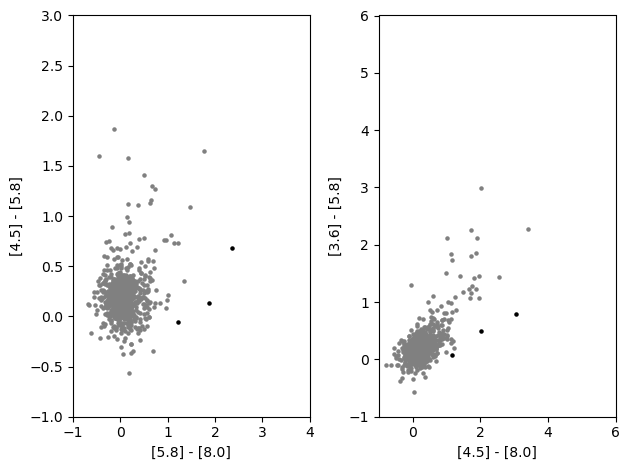

In [17]:
ax = plt.subplot(121)
catalog_masked.plot_CCD('5.8', '8.0', '4.5', '5.8', color='grey', s=5, ax=ax)
catalog_PAHgal.plot_CCD('5.8', '8.0', '4.5', '5.8', color='k', s=5, ax=ax)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 3)

ax = plt.subplot(122)
catalog_masked.plot_CCD('4.5', '8.0', '3.6', '5.8', color='grey', s=5, ax=ax)
catalog_PAHgal.plot_CCD('4.5', '8.0', '3.6', '5.8', color='k', s=5, ax=ax)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)

plt.tight_layout()

Next, isolate likely AGN. 

In [18]:
mask_AGN = cat_gl.color('4.5', '8.0') > 0.5
mask_AGN = np.logical_and(mask_AGN, cat_gl.band('4.5') > 13.5 + (cat_gl.color('4.5', '8.0') - 2.3)/0.4)
mask_AGN = np.logical_and(mask_AGN, cat_gl.band('4.5') > 13.5)

mask_AGNany = cat_gl.band('4.5') > 14 + (cat_gl.color('4.5', '8.0') - 0.5)
mask_AGNany = np.logical_or(mask_AGNany, cat_gl.band('4.5') > 14.5 - (cat_gl.color('4.5', '8.0') - 1.2)/0.3)
mask_AGNany = np.logical_or(mask_AGNany, cat_gl.band('4.5') > 14.5)

mask_AGN = np.logical_and(mask_AGN, mask_AGNany)

catalog_AGN = GlimpseCatalog(catalog[mask_AGN])
combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

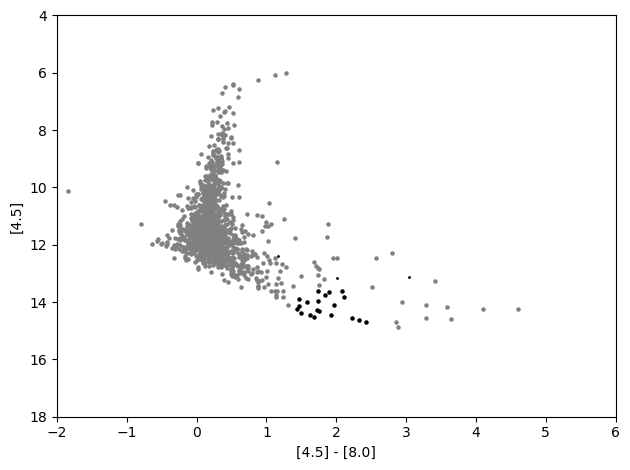

In [19]:
ax = plt.subplot(111)
catalog_masked.plot_CMD('4.5', '8.0', '4.5', color='grey', s=5, ax=ax)
catalog_AGN.plot_CMD('4.5', '8.0', '4.5', color='k', s=5, ax=ax)
catalog_PAHgal.plot_CMD('4.5', '8.0', '4.5', color='k', s=1, ax=ax)
ax.set_xlim(-2, 6)
ax.set_ylim(18, 4)
#plt.gca().invert_yaxis()

plt.tight_layout()

Then remove knots of shock emission.

In [20]:
mask_shock = cat_gl.color('3.6', '4.5') > (1.2/0.55) * (cat_gl.color('4.5', '5.8') - 0.3) + 0.8
mask_shock = np.logical_and(mask_shock, cat_gl.color('4.5', '5.8') <= 0.85)
mask_shock = np.logical_and(mask_shock, cat_gl.color('3.6', '4.5') > 1.05)

catalog_shock = GlimpseCatalog(catalog[mask_shock])
combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
combined_mask = np.logical_or(combined_mask, mask_shock)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

Gutermuth et al also includes selections that remove PAH emission, but those also involve taking into account the local surface density. 

$\sigma\{i,j\} = \frac{n-1}{\pi r_n^2\{i,j\}}$

n = 6

In [21]:
cat_m_coords = SkyCoord(catalog_masked.ra, catalog_masked.dec, unit=(u.deg, u.deg), frame='fk5')

cutout_W51 = Cutout(position, l*1.5, w*1.5)
fn_I4 = '/orange/adamginsburg/spitzer/GLIMPSE/GLM_04800+0000_mosaic_I4.fits'
cutout_W51_I4 = cutout_W51.get_cutout(fn_I4)
hdu_cutout = fits.PrimaryHDU(data=cutout_W51_I4.data, header=cutout_W51_I4.wcs.to_header())
ww_W51_fk5,shape_ = find_optimal_celestial_wcs(hdu_cutout, frame='icrs')
#cutout_W51_I4_reproj,_ = reproject.reproject_interp(hdu_cutout, ww_W51_fk5, shape_)

sigma = gutermuth_stellar_density(cat_m_coords, shape=shape_, wcs=ww_W51_fk5, k=6)

cutout_sigma = Cutout2D(sigma, position, size=(l,w), wcs=ww_W51_fk5)

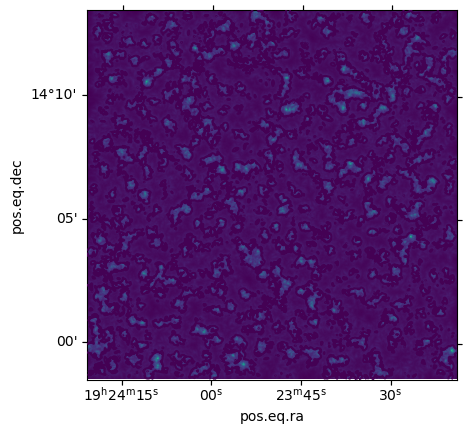

In [22]:
sigma[sigma<0.001]=np.nan
ax = plt.subplot(projection=cutout_sigma.wcs)
ax.imshow(cutout_sigma.data)
ax.contour(cutout_sigma.data, levels=[0.01])

In [23]:
sig = 0.01 # assuming this for the whole catalog for now

sig1 = sig*(cat_gl.color('4.5', '5.8'))
sig2 = sig*(cat_gl.color('3.6', '4.5'))

mask_PAH = cat_gl.color('3.6', '4.5') - sig2 <= 1.4 * (cat_gl.color('4.5', '5.8') + sig1 -0.7) + 0.15
mask_PAH = np.logical_and(mask_PAH, cat_gl.color('3.6', '4.5') - sig2 <= 1.65)

catalog_PAH = GlimpseCatalog(catalog[mask_PAH])
combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
combined_mask = np.logical_or(combined_mask, mask_shock)
combined_mask = np.logical_or(combined_mask, mask_PAH)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

(-1.0, 3.0)

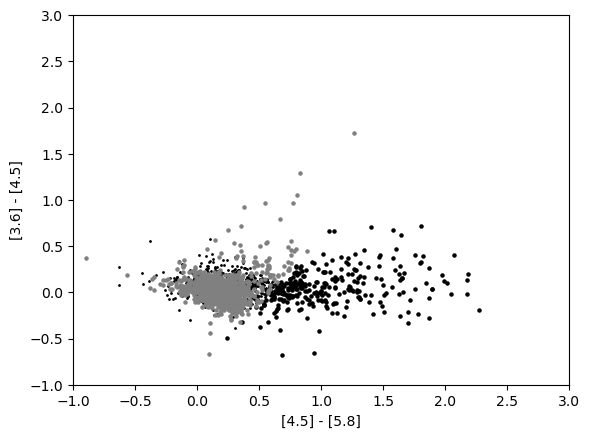

In [24]:
ax = plt.subplot(111)
catalog_PAHgal.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, ax=ax)
catalog_AGN.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, ax=ax)
catalog_shock.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=5, ax=ax)
catalog_PAH.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=5, ax=ax)
catalog_masked.plot_CCD('4.5', '5.8', '3.6', '4.5', color='grey', s=5, ax=ax)

#catalog_AGN.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
#catalog_PAHgal.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)

Now we can select for Class I YSOs using Gutermuth et al's selection criteria.

In [25]:
mask_yso1 = cat_gl.color('4.5', '5.8') > 0.7
mask_yso1 = np.logical_and(mask_yso1, cat_gl.color('3.6', '4.5') > 0.7)

combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
combined_mask = np.logical_or(combined_mask, mask_shock)
combined_mask = np.logical_or(combined_mask, mask_PAH)
yso1_mask = np.logical_and(~combined_mask, mask_yso1)
catalog_yso1 = GlimpseCatalog(catalog[yso1_mask])
combined_mask = np.logical_or(combined_mask, yso1_mask)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

(-1.0, 3.0)

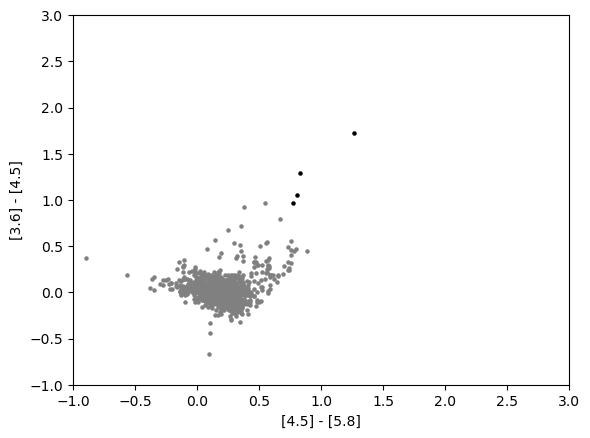

In [26]:
ax = plt.subplot(111)
catalog_masked.plot_CCD('4.5', '5.8', '3.6', '4.5', color='grey', s=5, ax=ax)
catalog_yso1.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=5, ax=ax)
#catalog_AGN.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
#catalog_PAHgal.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)

Let's also try to select for Class II YSO candidates. 

In [27]:
sig3 = sig*(cat_gl.color('4.5', '8.0'))
sig4 = sig*(cat_gl.color('3.6', '5.8'))

mask_yso2 = cat_gl.color('4.5', '8.0') - sig3 > 0.5
mask_yso2 = np.logical_and(mask_yso2, cat_gl.color('3.6', '5.8') - sig4 > 0.35)
mask_yso2 = np.logical_and(mask_yso2, cat_gl.color('3.6', '5.8') + sig4 <= (0.14/0.04)*(cat_gl.color('4.5', '8.0') - sig3 - 0.5) + 0.5)
mask_yso2 = np.logical_and(mask_yso2, cat_gl.color('3.6', '4.5') - sig4 > 0.15)

combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
combined_mask = np.logical_or(combined_mask, mask_shock)
combined_mask = np.logical_or(combined_mask, mask_PAH)
yso1_mask = np.logical_and(~combined_mask, mask_yso1)
combined_mask = np.logical_or(combined_mask, yso1_mask)
yso2_mask = np.logical_and(~combined_mask, mask_yso2)
catalog_yso2 = GlimpseCatalog(catalog[yso2_mask])
combined_mask = np.logical_or(combined_mask, yso2_mask)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

(-1.0, 3.0)

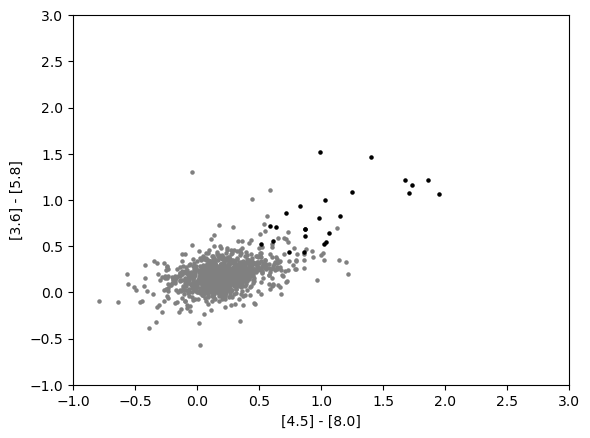

In [ ]:
ax = plt.subplot(111)
catalog_masked.plot_CCD('4.5', '8.0', '3.6', '5.8', color='grey', s=5, ax=ax)
catalog_yso2.plot_CCD('4.5', '8.0', '3.6', '5.8', color='k', s=5, ax=ax)
#catalog_AGN.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
#catalog_PAHgal.plot_CCD('4.5', '5.8', '3.6', '4.5', color='k', s=1, alpha=0.1, ax=ax)
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)

## Phase Two 

Next, we will use the $JHK_s$ bands to identify further YSOs. 

Using these bands requires deriving the intrinsic colors from the photometry.

In [47]:
C = ((1.17)**(-1) - (1.49)**(-1))**(-1)

HmK0 = (1.33 * (C*cat_gl.color('H', 'K') - cat_gl.color('3.6', '4.5')) - 0.133) / (1.33*C -1)
JmH0 = 0.58 * HmK0 + 0.52
I1mI20 = cat_gl.color('3.6', '4.5') - (cat_gl.color('H', 'K') - HmK0)*(1/1.49)
KmI10 = cat_gl.color('K', '3.6') - (cat_gl.color('H', 'K') - cat_gl.color('H', 'K'))*(1/1.49)

In [50]:
sig1_n = sig*cat_gl.color('3.6', '4.5')
sig2_n = sig*cat_gl.color('K', '3.6')

mask_phase2 = np.logical_or(np.isnan(np.array(cat_gl.band('5.8'))), np.isnan(np.array(cat_gl.band('8.0'))))
mask_phase2 = np.logical_and(mask_phase2, I1mI20 - sig1_n > 0.101)
mask_phase2 = np.logical_and(mask_phase2, KmI10 - sig2_n > 0)
mask_phase2 = np.logical_and(mask_phase2, KmI10 - sig2_n > -2.85714 * (I1mI20 -sig1_n -0.101) + 0.5)

catalog_phase2 = GlimpseCatalog(catalog[mask_phase2])
combined_mask = np.logical_or(mask_PAHgal, mask_AGN)
combined_mask = np.logical_or(combined_mask, mask_shock)
combined_mask = np.logical_or(combined_mask, mask_PAH)
yso1_mask = np.logical_and(~combined_mask, mask_yso1)
combined_mask = np.logical_or(combined_mask, yso1_mask)
yso2_mask = np.logical_and(~combined_mask, mask_yso2)
combined_mask = np.logical_or(combined_mask, yso2_mask)
phase2_mask = np.logical_and(~combined_mask, mask_phase2)
catalog_masked = GlimpseCatalog(catalog[~combined_mask])

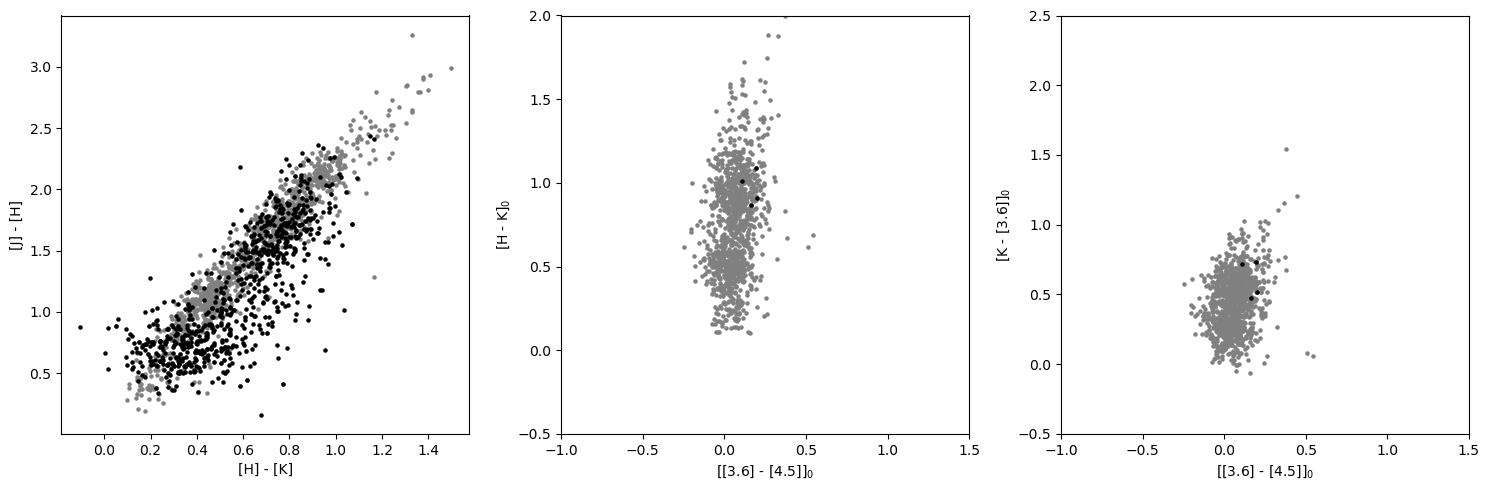

In [61]:
fig = plt.figure(figsize=(15, 5))

ax = plt.subplot(131)
catalog_masked.plot_CCD('H', 'K', 'J', 'H', color='grey', s=5, ax=ax)
catalog_phase2.plot_CCD('H', 'K', 'J', 'H', color='k', s=5, ax=ax)

ax = plt.subplot(132)
ax.scatter(I1mI20[~combined_mask], HmK0[~combined_mask], c='grey', s=5)
ax.scatter(I1mI20[phase2_mask], HmK0[phase2_mask], c='k', s=5)
ax.set_xlabel('[[3.6] - [4.5]]$_0$')
ax.set_ylabel('[H - K]$_0$')
ax.set_xlim(-1, 1.5)
ax.set_ylim(-0.5, 2.0)

ax = plt.subplot(133)
ax.scatter(I1mI20[~combined_mask], KmI10[~combined_mask], c='grey', s=5)
ax.scatter(I1mI20[phase2_mask], KmI10[phase2_mask], c='k', s=5)
ax.set_xlabel('[[3.6] - [4.5]]$_0$')
ax.set_ylabel('[K - [3.6]]$_0$')
ax.set_xlim(-1, 1.5)
ax.set_ylim(-0.5, 2.5)

plt.tight_layout()